In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve_discrete_are

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)


Using device: mps


In [2]:
import torch.nn as nn

class ControlledVanDerPolNODEFunc(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)
        )

    def forward(self, x, u):
        xu = torch.cat([x, u], dim=1)
        dxdt = self.net(xu)
        return dxdt

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

checkpoint = torch.load(
    "/Users/hotrongtai/Downloads/Pre_learning/NODE/controlled_vdp_node_best.pt",
    map_location=device
)

node_model = ControlledVanDerPolNODEFunc().to(device)
node_model.load_state_dict(checkpoint["model_state_dict"])

node_model.eval()

for p in node_model.parameters():
    p.requires_grad_(False)

mu = float(checkpoint["mu"])
b = float(checkpoint["b"])
dt = float(checkpoint["dt"])


print("Loaded NODE model.")
print("Checkpoint info:")
print("mu:", checkpoint["mu"])
print("b:", checkpoint["b"])
print("dt:", checkpoint["dt"])
print("T:", checkpoint["T"])
print("n_steps:", checkpoint["n_steps"])

Loaded NODE model.
Checkpoint info:
mu: 1.0
b: 1.0
dt: 0.07537688314914703
T: 15.0
n_steps: 200


In [4]:
x_init = torch.tensor([[2.0, 0.0]], device=device)
x_ref = torch.tensor([0.5, 0.0], device=device)
u_ref = torch.tensor([x_ref[0].item() / b], device=device)


In [5]:
def true_controlled_vdp_dynamics(x, u, mu=1.0, b=1.0):
    """
    Controlled Van der Pol:

        dx1/dt = x2
        dx2/dt = mu*(1 - x1^2)*x2 - x1 + b*u

    x shape: [batch_size, 2]
    u shape: [batch_size, 1]
    """

    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    dx1dt = x2
    dx2dt = mu * (1.0 - x1**2) * x2 - x1 + b * u

    return torch.cat([dx1dt, dx2dt], dim=1)

# Simulate the true dynamics using RK4 for better accuracy in the MPC loop
def rk4_step_true_controlled_vdp(x, u, dt, mu=1.0, b=1.0):
    """
    RK4 step for the true controlled Van der Pol dynamics.
    """

    k1 = true_controlled_vdp_dynamics(x, u, mu, b)
    k2 = true_controlled_vdp_dynamics(x + 0.5 * dt * k1, u, mu, b)
    k3 = true_controlled_vdp_dynamics(x + 0.5 * dt * k2, u, mu, b)
    k4 = true_controlled_vdp_dynamics(x + dt * k3, u, mu, b)

    x_next = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x_next

In [6]:
#Linearization of the continouos-model dynamics_func before put into MPC optimization loop
def rk4_step(dynamics_func, x, u, dt):
    k1 = dynamics_func(x, u)
    k2 = dynamics_func(x + 0.5 * dt * k1, u)
    k3 = dynamics_func(x + 0.5 * dt * k2, u)
    k4 = dynamics_func(x + dt * k3, u)

    x_next = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x_next


In [7]:
def rollout_dynamics(dynamics_func, x0, u_seq, dt):
    
    states = [x0.squeeze(0)]
    x = x0

    for k in range(u_seq.shape[0]):
        u_k = u_seq[k:k+1, :]   # shape [1, 1]

        x = rk4_step(
            dynamics_func=dynamics_func,
            x=x,
            u=u_k,
            dt=dt
        )

        states.append(x.squeeze(0))

    return torch.stack(states, dim=0)


In [8]:
def mpc_cost(states, u_seq, x_ref, u_ref, q, r, qf):
    """
    states shape: [Np + 1, 2]
    u_seq shape: [Np, 1]
    x_ref shape: [2]
    u_ref shape: [1]
    """

    # Tracking state error
    err = states[:-1] - x_ref
    state_cost = torch.sum(q * err**2)

    # Penalize input deviation from u_ref
    input_err = u_seq - u_ref
    input_cost = r * torch.sum(input_err**2)

    # Terminal cost
    terminal_err = states[-1] - x_ref
    terminal_cost = torch.sum(qf * terminal_err**2)

    return state_cost + input_cost + terminal_cost

In [9]:
def solve_mpc(
    prediction_func,
    x_current,
    x_ref,
    u_ref,
    Np=20,
    dt=0.075,
    num_iters=100,
    lr=0.03,
    u_max=1.0
):

    q = torch.tensor([10.0, 1.0], device=device)
    qf = torch.tensor([30.0, 5.0], device=device)
    r = torch.tensor(0.1, device=device)

    ratio = (u_ref / u_max).clamp(-0.95, 0.95)
    raw_init = torch.atanh(ratio).repeat(Np, 1).detach()
    raw_u = raw_init.clone().to(device).requires_grad_(True)
    
    optimizer = torch.optim.Adam([raw_u], lr=lr)

    cost_history = []

    for _ in range(num_iters):
        optimizer.zero_grad()

        u_seq = u_max * torch.tanh(raw_u)

        states = rollout_dynamics(
            dynamics_func=prediction_func,
            x0=x_current,
            u_seq=u_seq,
            dt=dt
        )

        cost = mpc_cost(
            states=states,
            u_seq=u_seq,
            x_ref=x_ref,
            u_ref=u_ref,
            q=q,
            r=r,
            qf=qf
        )

        cost.backward()
        optimizer.step()

        cost_history.append(cost.item())

    with torch.no_grad():
        u_opt = u_max * torch.tanh(raw_u)

        states_opt = rollout_dynamics(
            dynamics_func=prediction_func,
            x0=x_current,
            u_seq=u_opt,
            dt=dt
        )

    return u_opt.detach(), states_opt.detach(), cost_history



In [10]:
def simulate_closed_loop_mpc(
    prediction_func,
    plant_func,
    x_init,
    x_ref,
    u_ref,
    sim_steps=100,
    Np=20,
    dt=0.05,
    u_max=1.0,
    num_iters=100,
    lr=0.03
):
    """
    Closed-loop MPC .

    prediction_func:
        model insize MPC use to predict

    plant_func:
        true system use to update state after applying u0
    """

    x = x_init.clone().to(device)

    x_history = [x.squeeze(0).detach().cpu()]
    u_history = []

    for step in range(sim_steps):
        u_opt, _, _ = solve_mpc(
            prediction_func=prediction_func,
            x_current=x,
            x_ref=x_ref,
            u_ref=u_ref,
            Np=Np,
            dt=dt,
            u_max=u_max,
            num_iters=num_iters,
            lr=lr
        )

        u0 = u_opt[0:1, :]  # [1, 1]

        # Apply u0 to the true system
        x = rk4_step(
            dynamics_func=plant_func,
            x=x,
            u=u0,
            dt=dt
        )

        x_history.append(x.squeeze(0).detach().cpu())
        u_history.append(u0.squeeze(0).detach().cpu())

        if step % 10 == 0:
            print(
                f"Step {step:3d} | "
                f"x = {x.squeeze(0).detach().cpu().numpy()} | "
                f"u = {u0.item():.4f}"
            )

    x_history = torch.stack(x_history, dim=0)
    u_history = torch.stack(u_history, dim=0)

    return x_history, u_history

In [11]:
true_func = lambda x, u: true_controlled_vdp_dynamics(
    x=x,
    u=u,
    mu=mu,
    b=b
)

node_func = lambda x, u: node_model(x, u)

In [12]:
x_hist_node, u_hist_node = simulate_closed_loop_mpc(
    prediction_func=node_func,   
    plant_func=true_func,        
    x_init=x_init,
    x_ref=x_ref,
    u_ref=u_ref,
    sim_steps=200,
    Np=20,
    dt=dt,
    u_max=1.0,
    num_iters=200,
    lr=0.03
)

Step   0 | x = [ 1.9921817  -0.19985968] | u = -0.9637
Step  10 | x = [ 1.44914    -0.93718934] | u = 0.9353
Step  20 | x = [ 0.80484945 -0.84810144] | u = 0.9897
Step  30 | x = [ 0.1200233 -0.9672086] | u = 0.9917
Step  40 | x = [-0.5493412 -0.6577507] | u = 0.9897
Step  50 | x = [-0.6333524  0.5356079] | u = 0.9667
Step  60 | x = [-0.01403765  0.87094426] | u = -0.9822
Step  70 | x = [0.5255821  0.42377588] | u = -0.9311
Step  80 | x = [ 0.5181941  -0.23181783] | u = 0.6785
Step  90 | x = [ 0.3685879  -0.13894916] | u = 0.7212
Step 100 | x = [0.33448783 0.00523297] | u = 0.3872
Step 110 | x = [0.34332883 0.01124592] | u = 0.3222
Step 120 | x = [0.34862056 0.00335216] | u = 0.3376
Step 130 | x = [3.4974185e-01 3.3042135e-04] | u = 0.3476
Step 140 | x = [ 3.49753827e-01 -1.13347225e-04] | u = 0.3498
Step 150 | x = [ 3.4968355e-01 -5.9346246e-05] | u = 0.3498
Step 160 | x = [ 3.4965947e-01 -1.2200549e-05] | u = 0.3497
Step 170 | x = [ 3.49656105e-01 -1.13011254e-07] | u = 0.3497
Step 18

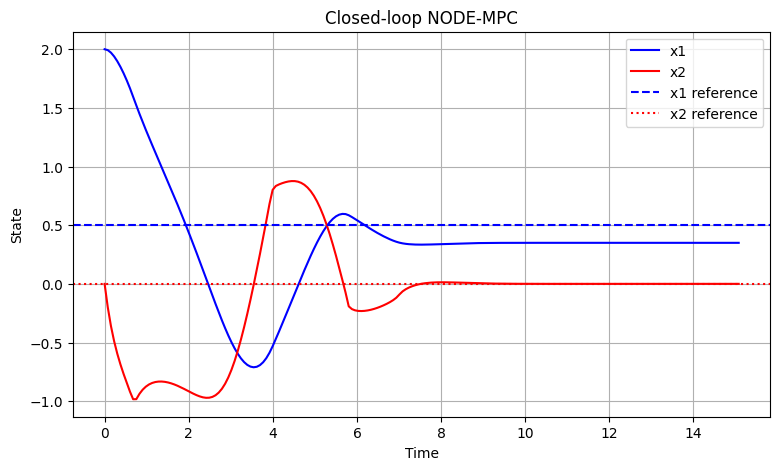

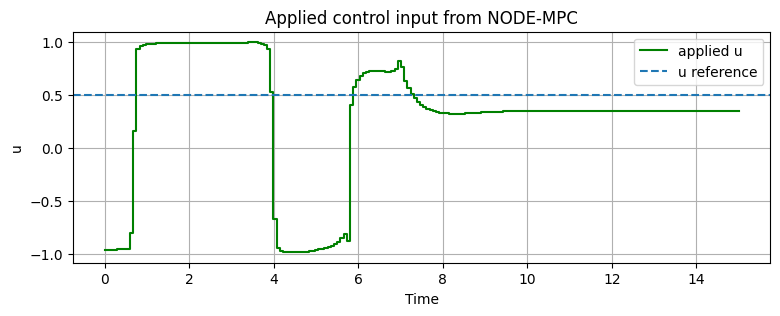

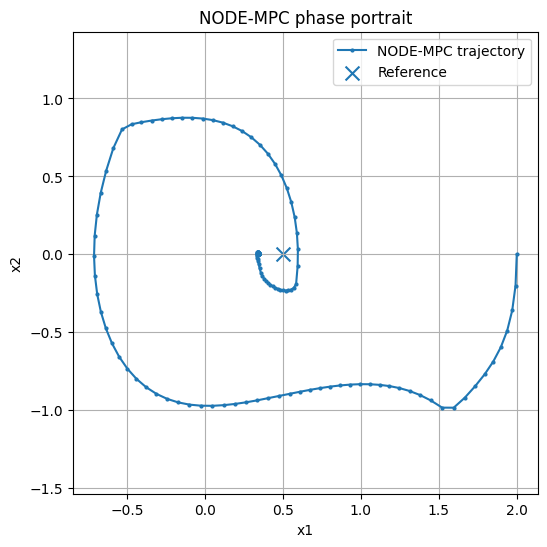

In [13]:
x_ref_cpu = x_ref.detach().cpu()
u_ref_cpu = u_ref.detach().cpu()

t_sim = torch.arange(x_hist_node.shape[0]) * dt
t_u = torch.arange(u_hist_node.shape[0]) * dt

plt.figure(figsize=(9, 5))
plt.plot(t_sim.numpy(), x_hist_node[:, 0].numpy(), label="x1", color="blue")
plt.plot(t_sim.numpy(), x_hist_node[:, 1].numpy(), label="x2", color="red")

plt.axhline(x_ref_cpu[0].item(), linestyle="--", label="x1 reference", color="blue")
plt.axhline(x_ref_cpu[1].item(), linestyle=":", label="x2 reference", color="red")

plt.xlabel("Time")
plt.ylabel("State")
plt.title("Closed-loop NODE-MPC")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 3))
plt.step(t_u.numpy(), u_hist_node[:, 0].numpy(), where="post", label="applied u", color="green")
plt.axhline(u_ref_cpu[0].item(), linestyle="--", label="u reference")
plt.xlabel("Time")
plt.ylabel("u")
plt.title("Applied control input from NODE-MPC")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(
    x_hist_node[:, 0].numpy(),
    x_hist_node[:, 1].numpy(),
    marker="o",
    markersize=2,
    label="NODE-MPC trajectory"
)

plt.scatter(
    [x_ref_cpu[0].item()],
    [x_ref_cpu[1].item()],
    marker="x",
    s=100,
    label="Reference"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("NODE-MPC phase portrait")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

In [14]:
def evaluate_closed_loop(x_hist, u_hist, x_ref, u_ref, state_names=("x1", "x2"), title="NODE-MPC"):
    """
    x_hist shape: [sim_steps + 1, 2]
    u_hist shape: [sim_steps, 1]
    x_ref shape: [2]
    u_ref shape: [1]
    """

    x_ref_cpu = x_ref.detach().cpu()
    u_ref_cpu = u_ref.detach().cpu()

    tracking_error = x_hist - x_ref_cpu
    input_error = u_hist - u_ref_cpu

    mae = torch.mean(torch.abs(tracking_error), dim=0)
    rmse = torch.sqrt(torch.mean(tracking_error**2, dim=0))

    final_state_error = tracking_error[-1]
    final_error_norm = torch.norm(final_state_error)

    control_effort = torch.sum(u_hist[:, 0] ** 2)
    mean_abs_u_minus_uref = torch.mean(torch.abs(input_error[:, 0]))

    # =========================
    # Print state tracking table
    # =========================
    print("=" * 72)
    print(f"{title:^72}")
    print("=" * 72)

    print(f"{'State':<8} {'MAE':>12} {'RMSE':>12} {'Final Error':>16}")
    print("-" * 72)

    for i, name in enumerate(state_names):
        print(
            f"{name:<8} "
            f"{mae[i].item():>12.6f} "
            f"{rmse[i].item():>12.6f} "
            f"{final_state_error[i].item():>16.6f}"
        )

    print("-" * 72)

    # =========================
    # Print control summary
    # =========================
    print(f"{'Final Error Norm':<30}: {final_error_norm.item():.6f}")
    print(f"{'Control Effort sum(u^2)':<30}: {control_effort.item():.6f}")
    print(f"{'Mean |u - u_ref|':<30}: {mean_abs_u_minus_uref.item():.6f}")
    print("=" * 72)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Final_state_error": final_state_error,
        "Final_error_norm": final_error_norm,
        "Control_effort": control_effort,
        "Mean_abs_u_minus_uref": mean_abs_u_minus_uref,
    }

In [15]:
metrics_node = evaluate_closed_loop(
    x_hist=x_hist_node,
    u_hist=u_hist_node,
    x_ref=x_ref,
    u_ref=u_ref,
    state_names=("x1", "x2"),
    title="Closed-loop NODE-MPC Evaluation"
)

                    Closed-loop NODE-MPC Evaluation                     
State             MAE         RMSE      Final Error
------------------------------------------------------------------------
x1           0.350531     0.520703        -0.150343
x2           0.283638     0.466433         0.000000
------------------------------------------------------------------------
Final Error Norm              : 0.150343
Control Effort sum(u^2)       : 91.826195
Mean |u - u_ref|              : 0.436652


In [16]:
# ============================================================
# Step 1: Compute A_d, B_d from trained NODE one-step RK4 map
# ============================================================


def node_one_step_flat(x_flat, u_flat, dt):
    """
    One-step discrete NODE map:

        x_next = f_theta^d(x, u)

    x_flat shape: [2]
    u_flat shape: [1]
    return shape: [2]
    """

    x = x_flat.unsqueeze(0)  # [1, 2]
    u = u_flat.unsqueeze(0)  # [1, 1]

    x_next = rk4_step(
        dynamics_func=node_func,
        x=x,
        u=u,
        dt=dt
    )

    return x_next.squeeze(0)



In [17]:
def compute_discrete_node_jacobians(node_func, x_ref, u_ref, dt):
    """
    Compute:

        A_d = d f_theta^d(x, u) / dx at (x_ref, u_ref)
        B_d = d f_theta^d(x, u) / du at (x_ref, u_ref)
    """

    x_ref_flat = x_ref.detach().clone().to(device).reshape(-1)
    u_ref_flat = u_ref.detach().clone().to(device).reshape(-1)

    def one_step_x(x_flat):
        return node_one_step_flat(
            x_flat=x_flat,
            u_flat=u_ref_flat,
            dt=dt
        )

    def one_step_u(u_flat):
        return node_one_step_flat(
            x_flat=x_ref_flat,
            u_flat=u_flat,
            dt=dt
        )

    A_d = torch.autograd.functional.jacobian(
        one_step_x,
        x_ref_flat
    )

    B_d = torch.autograd.functional.jacobian(
        one_step_u,
        u_ref_flat
    )

    return A_d.detach(), B_d.detach()

    



In [18]:
A_d, B_d = compute_discrete_node_jacobians(
    node_func=node_func,
    x_ref=x_ref,
    u_ref=u_ref,
    dt=dt
)

In [19]:
# Check fixed-point residual
# r  = f_theta^d(x_ref, u_ref) - x_ref
# Ideally this should be close to zero since (x_ref, u_ref) is the equilibrium point of the true system and the NODE should have learned to match it.
# We compute this to verify that the linearization is done around a point that is close to an equilibrium of the NODE dynamics, which is important for the validity of the linearization in MPC.
# If residual is large:
#   - x_ref, u_ref might not be an equilibrium of the NODE dynamics
#   - x_ref might not be fall into the training data distribution of the NODE
#   - u_ref might not be fall into the input range training  of the NODE
#   - Node prediction around (x_ref, u_ref) might not be accurate
#
with torch.no_grad():
    x_ref_batch = x_ref.detach().clone().to(device).reshape(1, -1)
    u_ref_batch = u_ref.detach().clone().to(device).reshape(1, -1)

    x_next_ref = rk4_step(
        dynamics_func=node_func,
        x=x_ref_batch,
        u=u_ref_batch,
        dt=dt
    )

    fixed_point_residual = x_next_ref.squeeze(0) - x_ref.reshape(-1)


# Print result
print("=" * 60)
print("Discrete NODE Linearization")
print("=" * 60)

print("A_d = d f_theta^d / d x")
print(f"{'':<8} {'x1':>12} {'x2':>12}")
for i, row_name in enumerate(["x1_next", "x2_next"]):
    print(
        f"{row_name:<8} "
        f"{A_d[i, 0].item():>12.6f} "
        f"{A_d[i, 1].item():>12.6f}"
    )

print("\nB_d = d f_theta^d / d u")
print(f"{'':<8} {'u':>12}")
for i, row_name in enumerate(["x1_next", "x2_next"]):
    print(
        f"{row_name:<8} "
        f"{B_d[i, 0].item():>12.6f}"
    )

print("\nFixed-point check")
print(f"{'Residual x1':<20}: {fixed_point_residual[0].item():.6e}")
print(f"{'Residual x2':<20}: {fixed_point_residual[1].item():.6e}")
print(f"{'Residual norm':<20}: {torch.norm(fixed_point_residual).item():.6e}")

print("=" * 60)

Discrete NODE Linearization
A_d = d f_theta^d / d x
                   x1           x2
x1_next      0.993356     0.107573
x2_next     -0.088137     1.103056

B_d = d f_theta^d / d u
                    u
x1_next      0.003827
x2_next      0.090476

Fixed-point check
Residual x1         : 2.224749e-02
Residual x2         : 5.272236e-03
Residual norm       : 2.286367e-02


In [20]:
# Solve Discrete Algebraic Riccati Equation (DARE) to get P_f
# We have A_d, B_d then we can solve the discrete-time algebraic Riccati equation (DARE) to get the terminal cost matrix P_f for MPC design.

#           K_f = (B_d^T P_f B_d + R*)^(-1) (B_d^T P_f A_d)

# ============================================================
# Step 2.1: Check controllability of (A_d, B_d)
# ============================================================

def check_controllability(A_d, B_d):
    """
    Check controllability of:
        e_{k+1} = A_d e_k + B_d v_k
    """

    n = A_d.shape[0]
    controllability_blocks = []

    A_power = torch.eye(n, device=A_d.device, dtype=A_d.dtype)

    for _ in range(n):
        controllability_blocks.append(A_power @ B_d)
        A_power = A_d @ A_power

    C = torch.cat(controllability_blocks, dim=1)

    # MPS no support for matrix_rank/SVD
    # so move C to CPU to compute rank
    rank_C = torch.linalg.matrix_rank(C.detach().cpu())

    return C, rank_C



In [21]:
Cmat, rank_C = check_controllability(A_d, B_d)

print("=" * 60)
print("Controllability Check")
print("=" * 60)
print("Controllability matrix:")
print(Cmat.detach().cpu())
print(f"Rank: {rank_C.item()} / {A_d.shape[0]}")
print("=" * 60)

Controllability Check
Controllability matrix:
tensor([[0.0038, 0.0135],
        [0.0905, 0.0995]])
Rank: 2 / 2


In [22]:
def solve_dare_for_terminal_ingredients(A_d, B_d, Q_star, R_star, device):
    """
    Solve DARE and compute terminal feedback gain.

    Returns:
        P_f  : terminal penalty matrix
        K_f  : terminal feedback gain
        A_CL : closed-loop matrix A_d - B_d K_f
    """

    A_np = A_d.detach().cpu().numpy()
    B_np = B_d.detach().cpu().numpy()
    Q_np = Q_star.detach().cpu().numpy()
    R_np = R_star.detach().cpu().numpy()

    P_np = solve_discrete_are(A_np, B_np, Q_np, R_np)

    K_np = np.linalg.solve(
        R_np + B_np.T @ P_np @ B_np,
        B_np.T @ P_np @ A_np
    )

    Acl_np = A_np - B_np @ K_np

    P_f = torch.tensor(P_np, device=device, dtype=A_d.dtype)
    K_f = torch.tensor(K_np, device=device, dtype=A_d.dtype)
    A_CL = torch.tensor(Acl_np, device=device, dtype=A_d.dtype)

    return P_f, K_f, A_CL


In [23]:
# -----------------------------
# Solve DARE
# -----------------------------
# Choose stage and Riccati weights

Q = torch.diag(torch.tensor([10.0, 1.0], device=device, dtype=A_d.dtype))
R = torch.diag(torch.tensor([0.1], device=device, dtype=A_d.dtype))

Q_star = 1.2 * Q
R_star = 1.2 * R

P_f, K_f, A_CL = solve_dare_for_terminal_ingredients(
    A_d=A_d,
    B_d=B_d,
    Q_star=Q_star,
    R_star=R_star,
    device=device
)


# -----------------------------
# Diagnostics
# -----------------------------

# MPS does not support eigvals well, switch to CPU to calculate eigenvalues
eig_P = torch.linalg.eigvals(P_f.detach().cpu()).real

eig_Acl = torch.linalg.eigvals(A_CL.detach().cpu())
eig_abs = torch.abs(eig_Acl)


print("=" * 70)
print("Step 2: DARE Terminal Ingredients")
print("=" * 70)

print("\nControllability matrix:")
print(Cmat.detach().cpu())

print(f"\nRank(C): {rank_C.item()} / {A_d.shape[0]}")

print("\nQ:")
print(Q.detach().cpu())

print("\nR:")
print(R.detach().cpu())

print("\nQ_star:")
print(Q_star.detach().cpu())

print("\nR_star:")
print(R_star.detach().cpu())

print("\nP_f:")
print(P_f.detach().cpu())

print("\nEigenvalues of P_f:")
print(eig_P)

print("\nP_f positive definite:")
print(bool(torch.all(eig_P > 0)))

print("\nK_f:")
print(K_f.detach().cpu())

print("\nA_CL = A_d - B_d K_f:")
print(A_CL.detach().cpu())

print("\nEigenvalues of A_CL:")
print(eig_Acl)

print("\nAbs eigenvalues of A_CL:")
print(eig_abs)

print("\nA_CL Schur stable:")
print(bool(torch.all(eig_abs < 1.0)))

print("=" * 70)



Step 2: DARE Terminal Ingredients

Controllability matrix:
tensor([[0.0038, 0.0135],
        [0.0905, 0.0995]])

Rank(C): 2 / 2

Q:
tensor([[10.,  0.],
        [ 0.,  1.]])

R:
tensor([[0.1000]])

Q_star:
tensor([[12.0000,  0.0000],
        [ 0.0000,  1.2000]])

R_star:
tensor([[0.1200]])

P_f:
tensor([[75.0033, 13.1919],
        [13.1919, 10.6447]])

Eigenvalues of P_f:
tensor([77.6024,  8.0456])

P_f positive definite:
True

K_f:
tensor([[6.3552, 5.8762]])

A_CL = A_d - B_d K_f:
tensor([[ 0.9690,  0.0851],
        [-0.6631,  0.5714]])

Eigenvalues of A_CL:
tensor([0.7702+0.1300j, 0.7702-0.1300j])

Abs eigenvalues of A_CL:
tensor([0.7811, 0.7811])

A_CL Schur stable:
True


In [24]:
def terminal_feedback_controller(x, x_ref, u_ref, K_f):
    """
    Terminal feedback law:

        u = u_ref - K_f (x - x_ref)

    x shape: [batch_size, state_dim]
    x_ref shape: [state_dim]
    u_ref shape: [input_dim]
    K_f shape: [input_dim, state_dim]

    return:
        u shape: [batch_size, input_dim]
    """

    e = x - x_ref.unsqueeze(0)

    u = u_ref.unsqueeze(0) - e @ K_f.T

    return u

In [25]:
x_test = torch.tensor(
    [
        [0.8, 0.0],
        [0.9, 0.0],
        [0.8, 0.1],
        [0.7, -0.1],
    ],
    device=device,
    dtype=K_f.dtype
)

u_terminal = terminal_feedback_controller(
    x=x_test,
    x_ref=x_ref,
    u_ref=u_ref,
    K_f=K_f
)
print(x_test.shape)
print(x_ref)
print("=" * 60)
print("Terminal Feedback Controller")
print("=" * 60)

for i in range(x_test.shape[0]):
    print(
        f"x = {x_test[i].detach().cpu().numpy()} "
        f"-> u_terminal = {u_terminal[i].detach().cpu().numpy()}"
    )

print("=" * 60)

torch.Size([4, 2])
tensor([0.5000, 0.0000], device='mps:0')
Terminal Feedback Controller
x = [0.8 0. ] -> u_terminal = [-1.4065732]
x = [0.9 0. ] -> u_terminal = [-2.0420973]
x = [0.8 0.1] -> u_terminal = [-1.9941885]
x = [ 0.7 -0.1] -> u_terminal = [-0.18343323]


In [26]:
def terminal_feedback_controller_clipped(x, x_ref, u_ref, K_f, u_min, u_max):
    """
    Terminal feedback law with input clipping.
    """

    e = x - x_ref.unsqueeze(0)

    u = u_ref.unsqueeze(0) - e @ K_f.T

    u = torch.clamp(u, min=u_min.item(), max=u_max.item())

    return u

In [27]:
u_min = torch.tensor([-1.0], device=device, dtype=K_f.dtype)
u_max_tensor = torch.tensor([1.0], device=device, dtype=K_f.dtype)

u_terminal_clipped = terminal_feedback_controller_clipped(
    x=x_test,
    x_ref=x_ref,
    u_ref=u_ref,
    K_f=K_f,
    u_min=u_min,
    u_max=u_max_tensor
)

print(u_terminal_clipped.detach().cpu())

tensor([[-1.0000],
        [-1.0000],
        [-1.0000],
        [-0.1834]])


In [28]:
def simulate_linear_terminal_error(A_CL, e0, steps=20):
    e = e0.clone()
    e_hist = [e.detach().cpu()]

    for _ in range(steps):
        e = A_CL @ e
        e_hist.append(e.detach().cpu())

    return torch.stack(e_hist)


e0 = torch.tensor([0.1, 0.0], device=device, dtype=A_CL.dtype)

e_hist = simulate_linear_terminal_error(
    A_CL=A_CL,
    e0=e0,
    steps=20
)

print("=" * 60)
print("Linear Terminal Error Simulation")
print("=" * 60)

for k in range(e_hist.shape[0]):
    print(
        f"k={k:<2d} "
        f"e1={e_hist[k, 0].item():> .6f} "
        f"e2={e_hist[k, 1].item():> .6f} "
        f"norm={torch.norm(e_hist[k]).item():> .6f}"
    )

print("=" * 60)

Linear Terminal Error Simulation
k=0  e1= 0.100000 e2= 0.000000 norm= 0.100000
k=1  e1= 0.096903 e2=-0.066313 norm= 0.117421
k=2  e1= 0.088260 e2=-0.102151 norm= 0.134999
k=3  e1= 0.076836 e2=-0.116898 norm= 0.139889
k=4  e1= 0.064510 e2=-0.117749 norm= 0.134262
k=5  e1= 0.052494 e2=-0.110061 norm= 0.121939
k=6  e1= 0.041504 e2=-0.097700 norm= 0.106150
k=7  e1= 0.031906 e2=-0.083349 norm= 0.089247
k=8  e1= 0.023827 e2=-0.068784 norm= 0.072794
k=9  e1= 0.017237 e2=-0.055104 norm= 0.057737
k=10 e1= 0.012014 e2=-0.042917 norm= 0.044567
k=11 e1= 0.007991 e2=-0.032490 norm= 0.033458
k=12 e1= 0.004979 e2=-0.023864 norm= 0.024378
k=13 e1= 0.002794 e2=-0.016938 norm= 0.017167
k=14 e1= 0.001267 e2=-0.011531 norm= 0.011601
k=15 e1= 0.000246 e2=-0.007429 norm= 0.007433
k=16 e1=-0.000393 e2=-0.004409 norm= 0.004426
k=17 e1=-0.000756 e2=-0.002258 norm= 0.002381
k=18 e1=-0.000925 e2=-0.000789 norm= 0.001216
k=19 e1=-0.000963 e2= 0.000163 norm= 0.000977
k=20 e1=-0.000920 e2= 0.000732 norm= 0.001175


In [29]:
# Compute Lyapunov function value V = e^T P_f e along the trajectory to verify decrease
# Since P_f is the solution to the DARE, we should have:
#  Delta V = V(e_{k+1}) - V(e_k) = e_k^T (A_CL^T P_f A_CL - P_f) e_k < 0 for all e_k != 0

def lyapunov_value(e, P_f):
    """
    e shape: [state_dim] or [batch_size, state_dim]
    """

    if e.dim() == 1:
        return e @ P_f @ e

    return torch.einsum("bi,ij,bj->b", e, P_f, e)


print("=" * 60)
print("Lyapunov Decrease under Terminal Feedback")
print("=" * 60)

for k in range(e_hist.shape[0] - 1):
    e_now = e_hist[k].to(device)
    e_next = e_hist[k + 1].to(device)

    V_now = lyapunov_value(e_now, P_f)
    V_next = lyapunov_value(e_next, P_f)

    print(
        f"k={k:<2d} "
        f"V_now={V_now.item():> .6f} "
        f"V_next={V_next.item():> .6f} "
        f"Delta V={V_next.item() - V_now.item():> .6f}"
    )

print("=" * 60)

Lyapunov Decrease under Terminal Feedback
k=0  V_now= 0.750033 V_next= 0.581566 Delta V=-0.168467
k=1  V_now= 0.581566 V_next= 0.457468 Delta V=-0.124098
k=2  V_now= 0.457468 V_next= 0.351282 Delta V=-0.106186
k=3  V_now= 0.351282 V_next= 0.259306 Delta V=-0.091976
k=4  V_now= 0.259306 V_next= 0.183191 Delta V=-0.076115
k=5  V_now= 0.183191 V_next= 0.123822 Delta V=-0.059369
k=6  V_now= 0.123822 V_next= 0.080140 Delta V=-0.043682
k=7  V_now= 0.080140 V_next= 0.049703 Delta V=-0.030437
k=8  V_now= 0.049703 V_next= 0.029546 Delta V=-0.020157
k=9  V_now= 0.029546 V_next= 0.016828 Delta V=-0.012718
k=10 V_now= 0.016828 V_next= 0.009176 Delta V=-0.007652
k=11 V_now= 0.009176 V_next= 0.004787 Delta V=-0.004389
k=12 V_now= 0.004787 V_next= 0.002391 Delta V=-0.002396
k=13 V_now= 0.002391 V_next= 0.001150 Delta V=-0.001240
k=14 V_now= 0.001150 V_next= 0.000544 Delta V=-0.000607
k=15 V_now= 0.000544 V_next= 0.000264 Delta V=-0.000280
k=16 V_now= 0.000264 V_next= 0.000142 Delta V=-0.000122
k=17 V

In [30]:
def mpc_cost_with_terminal_pf(states, u_seq, x_ref, u_ref, Q, R, P_f):
    """
    MPC cost with Riccati terminal penalty:

        J = sum_{k=0}^{Np-1} [e_k^T Q e_k + v_k^T R v_k]
            + e_N^T P_f e_N

    states shape: [Np + 1, 2]
    u_seq shape: [Np, 1]
    x_ref shape: [2]
    u_ref shape: [1]
    Q shape: [2, 2]
    R shape: [1, 1]
    P_f shape: [2, 2]
    """

    # e_k = x_k - x_ref
    state_err = states[:-1] - x_ref.unsqueeze(0)      # [Np, 2]

    # v_k = u_k - u_ref
    input_err = u_seq - u_ref.unsqueeze(0)            # [Np, 1]

    # sum e_k^T Q e_k
    state_cost = torch.einsum(
        "ki,ij,kj->",
        state_err,
        Q,
        state_err
    )

    # sum v_k^T R v_k
    input_cost = torch.einsum(
        "ki,ij,kj->",
        input_err,
        R,
        input_err
    )

    # e_N = x_N - x_ref
    terminal_err = states[-1] - x_ref                 # [2]

    # e_N^T P_f e_N
    terminal_cost = terminal_err @ P_f @ terminal_err

    total_cost = state_cost + input_cost + terminal_cost

    return total_cost

In [31]:
def solve_mpc(
    prediction_func,
    x_current,
    x_ref,
    u_ref,
    Q,
    R,
    P_f,
    Np=20,
    dt=0.075,
    num_iters=80,
    lr=0.001,
    u_max=1.0
):
    """
    Solve NODE-MPC using Riccati terminal penalty P_f.
    """

    # Warn start 
    ratio = (u_ref / u_max).clamp(-0.95, 0.95)
    raw_init = torch.atanh(ratio).repeat(Np, 1).detach()
    raw_u = raw_init.clone().to(device).requires_grad_(True)

    optimizer = torch.optim.Adam([raw_u], lr=lr)

    cost_history = []

    for _ in range(num_iters):
        optimizer.zero_grad()

        u_seq = u_max * torch.tanh(raw_u)

        states = rollout_dynamics(
            dynamics_func=prediction_func,
            x0=x_current,
            u_seq=u_seq,
            dt=dt
        )

        cost = mpc_cost_with_terminal_pf(
            states=states,
            u_seq=u_seq,
            x_ref=x_ref,
            u_ref=u_ref,
            Q=Q,
            R=R,
            P_f=P_f
        )

        cost.backward()
        optimizer.step()

        cost_history.append(cost.item())

    with torch.no_grad():
        u_opt = u_max * torch.tanh(raw_u)

        states_opt = rollout_dynamics(
            dynamics_func=prediction_func,
            x0=x_current,
            u_seq=u_opt,
            dt=dt
        )

    return u_opt.detach(), states_opt.detach(), cost_history

In [32]:
def simulate_closed_loop_mpc(
    prediction_func,
    plant_func,
    x_init,
    x_ref,
    u_ref,
    Q,
    R,
    P_f,
    sim_steps=100,
    Np=20,
    dt=0.075,
    u_max=1.0,
    num_iters=80,
    lr=0.001
):
    """
    Closed-loop NODE-MPC with Riccati terminal penalty.
    """

    x = x_init.clone().to(device)

    x_history = [x.squeeze(0).detach().cpu()]
    u_history = []

    for step in range(sim_steps):
        u_opt, _, _ = solve_mpc(
            prediction_func=prediction_func,
            x_current=x,
            x_ref=x_ref,
            u_ref=u_ref,
            Q=Q,
            R=R,
            P_f=P_f,
            Np=Np,
            dt=dt,
            u_max=u_max,
            num_iters=num_iters,
            lr=lr
        )

        u0 = u_opt[0:1, :]  # [1, 1]

        x = rk4_step(
            dynamics_func=plant_func,
            x=x,
            u=u0,
            dt=dt
        )

        x_history.append(x.squeeze(0).detach().cpu())
        u_history.append(u0.squeeze(0).detach().cpu())

        if step % 10 == 0:
            print(
                f"Step {step:3d} | "
                f"x = {x.squeeze(0).detach().cpu().numpy()} | "
                f"u = {u0.item():.4f}"
            )

    x_history = torch.stack(x_history, dim=0)
    u_history = torch.stack(u_history, dim=0)

    return x_history, u_history

In [33]:
Q = torch.diag(torch.tensor([10.0, 1.0], device=device, dtype=P_f.dtype))
R = torch.diag(torch.tensor([0.1], device=device, dtype=P_f.dtype))

In [42]:
x_hist_node_pf, u_hist_node_pf = simulate_closed_loop_mpc(
    prediction_func=node_func,
    plant_func=true_func,
    x_init=x_init,
    x_ref=x_ref,
    u_ref=u_ref,
    Q=Q,
    R=R,
    P_f=P_f,
    sim_steps=200,
    Np=20,
    dt=dt,
    u_max=1.0,
    num_iters=300,
    lr=0.05
)

Step   0 | x = [ 1.9921128  -0.20162295] | u = -0.9899
Step  10 | x = [ 1.4539107 -0.873268 ] | u = 0.9670
Step  20 | x = [ 0.85772014 -0.774117  ] | u = 0.9976
Step  30 | x = [ 0.24590144 -0.8479725 ] | u = 0.9982
Step  40 | x = [-0.34896323 -0.62269807] | u = 0.9970
Step  50 | x = [-0.4870172   0.37490827] | u = 0.9810
Step  60 | x = [0.05951801 0.75402015] | u = -0.9837
Step  70 | x = [0.4602896  0.19970384] | u = -0.8270
Step  80 | x = [ 0.41655117 -0.1235939 ] | u = 0.6207
Step  90 | x = [ 0.36763024 -0.02238948] | u = 0.4551
Step 100 | x = [ 0.36158296 -0.00046027] | u = 0.3719
Step 110 | x = [0.36229753 0.00118881] | u = 0.3601
Step 120 | x = [3.6281323e-01 2.3631382e-04] | u = 0.3617
Step 130 | x = [ 3.6284691e-01 -4.8188285e-05] | u = 0.3628
Step 140 | x = [ 3.6281437e-01 -2.6027108e-05] | u = 0.3629
Step 150 | x = [ 3.6280611e-01 -1.0983631e-06] | u = 0.3628
Step 160 | x = [3.6280704e-01 1.7422177e-06] | u = 0.3628
Step 170 | x = [3.6280781e-01 3.5281536e-07] | u = 0.3628
Ste

In [43]:
metrics_node_pf = evaluate_closed_loop(
    x_hist=x_hist_node_pf,
    u_hist=u_hist_node_pf,
    x_ref=x_ref,
    u_ref=u_ref,
    state_names=("x1", "x2"),
    title="NODE-MPC with Riccati Terminal Cost P_f"
)

                NODE-MPC with Riccati Terminal Cost P_f                 
State             MAE         RMSE      Final Error
------------------------------------------------------------------------
x1           0.320600     0.479104        -0.137192
x2           0.241261     0.415051        -0.000000
------------------------------------------------------------------------
Final Error Norm              : 0.137192
Control Effort sum(u^2)       : 87.234222
Mean |u - u_ref|              : 0.396202


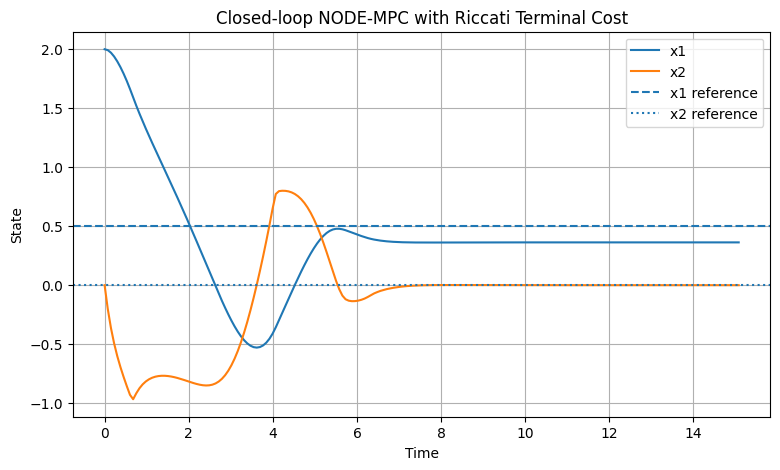

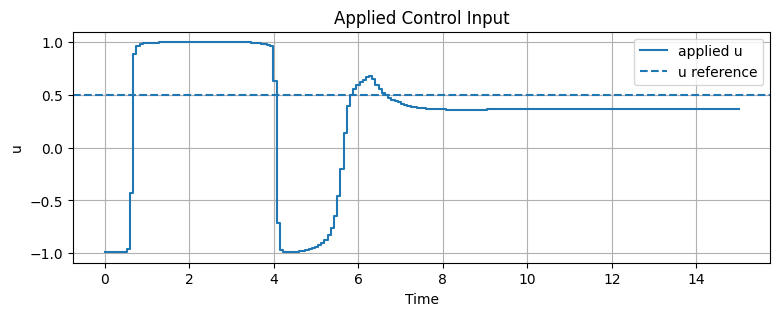

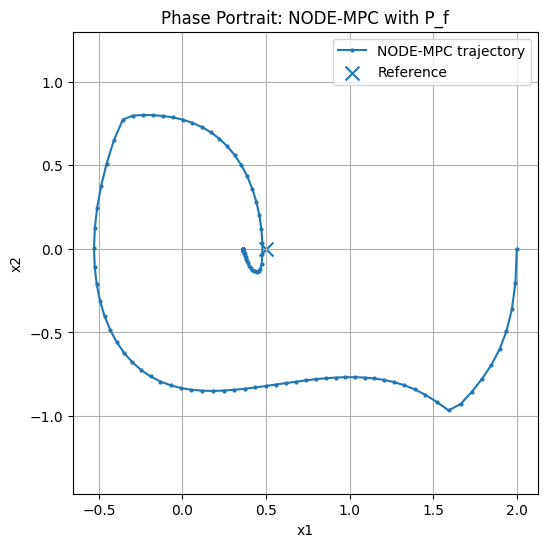

In [44]:
x_ref_cpu = x_ref.detach().cpu()
u_ref_cpu = u_ref.detach().cpu()

t_sim = torch.arange(x_hist_node_pf.shape[0]) * dt
t_u = torch.arange(u_hist_node_pf.shape[0]) * dt

plt.figure(figsize=(9, 5))
plt.plot(t_sim.numpy(), x_hist_node_pf[:, 0].numpy(), label="x1")
plt.plot(t_sim.numpy(), x_hist_node_pf[:, 1].numpy(), label="x2")

plt.axhline(x_ref_cpu[0].item(), linestyle="--", label="x1 reference")
plt.axhline(x_ref_cpu[1].item(), linestyle=":", label="x2 reference")

plt.xlabel("Time")
plt.ylabel("State")
plt.title("Closed-loop NODE-MPC with Riccati Terminal Cost")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(9, 3))
plt.step(t_u.numpy(), u_hist_node_pf[:, 0].numpy(), where="post", label="applied u")
plt.axhline(u_ref_cpu[0].item(), linestyle="--", label="u reference")

plt.xlabel("Time")
plt.ylabel("u")
plt.title("Applied Control Input")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(6, 6))
plt.plot(
    x_hist_node_pf[:, 0].numpy(),
    x_hist_node_pf[:, 1].numpy(),
    marker="o",
    markersize=2,
    label="NODE-MPC trajectory"
)

plt.scatter(
    [x_ref_cpu[0].item()],
    [x_ref_cpu[1].item()],
    marker="x",
    s=100,
    label="Reference"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Phase Portrait: NODE-MPC with P_f")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

In [46]:
def mpc_cost_with_terminal_set_soft(
    states,
    u_seq,
    x_ref,
    u_ref,
    Q,
    R,
    P_f,
    alpha=None,
    lambda_alpha=0.0,
    return_info=False
):
    """
    MPC cost with Riccati terminal cost and soft terminal set constraint.

    Objective:

        J = sum e_k^T Q e_k
          + sum v_k^T R v_k
          + e_N^T P_f e_N
          + lambda_alpha * max(0, e_N^T P_f e_N - alpha)^2

    states shape: [Np + 1, 2]
    u_seq shape: [Np, 1]
    """

    # Stage state error
    state_err = states[:-1] - x_ref.unsqueeze(0)      # [Np, 2]

    # Stage input error
    input_err = u_seq - u_ref.unsqueeze(0)            # [Np, 1]

    # sum e_k^T Q e_k
    state_cost = torch.einsum(
        "ki,ij,kj->",
        state_err,
        Q,
        state_err
    )

    # sum v_k^T R v_k
    input_cost = torch.einsum(
        "ki,ij,kj->",
        input_err,
        R,
        input_err
    )

    # Terminal error
    terminal_err = states[-1] - x_ref                 # [2]

    # V_f(e_N) = e_N^T P_f e_N
    terminal_value = terminal_err @ P_f @ terminal_err

    # Terminal cost
    terminal_cost = terminal_value

    # Soft terminal set penalty
    if alpha is None or lambda_alpha == 0.0:
        terminal_set_violation = torch.zeros(
            (),
            device=states.device,
            dtype=states.dtype
        )
        terminal_set_penalty = torch.zeros(
            (),
            device=states.device,
            dtype=states.dtype
        )
    else:
        alpha_tensor = torch.as_tensor(
            alpha,
            device=states.device,
            dtype=states.dtype
        )

        terminal_set_violation = torch.relu(
            terminal_value - alpha_tensor
        )

        terminal_set_penalty = lambda_alpha * terminal_set_violation**2

    total_cost = (
        state_cost
        + input_cost
        + terminal_cost
        + terminal_set_penalty
    )

    if return_info:
        info = {
            "state_cost": state_cost,
            "input_cost": input_cost,
            "terminal_value": terminal_value,
            "terminal_cost": terminal_cost,
            "terminal_set_violation": terminal_set_violation,
            "terminal_set_penalty": terminal_set_penalty,
            "total_cost": total_cost,
        }

        return total_cost, info

    return total_cost

In [50]:
def solve_mpc(
    prediction_func,
    x_current,
    x_ref,
    u_ref,
    Q,
    R,
    P_f,
    alpha=None,
    lambda_alpha=0.0,
    Np=20,
    dt=0.075,
    num_iters=200,
    lr=0.02,
    u_max=1.0
):
    """
    Solve NODE-MPC with:
        terminal cost     : e_N^T P_f e_N
        soft terminal set : max(0, e_N^T P_f e_N - alpha)^2

    MPC keeps the final optimized u_seq after num_iters,
    then closed-loop applies only u0.
    """

    # Warn start 
    ratio = (u_ref / u_max).clamp(-0.95, 0.95)
    raw_init = torch.atanh(ratio).repeat(Np, 1).detach()
    raw_u = raw_init.clone().to(device).requires_grad_(True)

    optimizer = torch.optim.Adam([raw_u], lr=lr)

    cost_history = []

    for it in range(num_iters):
        optimizer.zero_grad()

        u_seq = u_max * torch.tanh(raw_u)

        states = rollout_dynamics(
            dynamics_func=prediction_func,
            x0=x_current,
            u_seq=u_seq,
            dt=dt
        )

        cost, info = mpc_cost_with_terminal_set_soft(
            states=states,
            u_seq=u_seq,
            x_ref=x_ref,
            u_ref=u_ref,
            Q=Q,
            R=R,
            P_f=P_f,
            alpha=alpha,
            lambda_alpha=lambda_alpha,
            return_info=True
        )

        cost.backward()
        optimizer.step()

        cost_history.append(cost.item())


    with torch.no_grad():
        u_opt = u_max * torch.tanh(raw_u)

        states_opt = rollout_dynamics(
            dynamics_func=prediction_func,
            x0=x_current,
            u_seq=u_opt,
            dt=dt
        )

        _, info_tensor = mpc_cost_with_terminal_set_soft(
            states=states_opt,
            u_seq=u_opt,
            x_ref=x_ref,
            u_ref=u_ref,
            Q=Q,
            R=R,
            P_f=P_f,
            alpha=alpha,
            lambda_alpha=lambda_alpha,
            return_info=True
        )

    info_final = {
        k: v.detach().cpu().item()
        for k, v in info_tensor.items()
    }

    final_cost = cost_history[-1]

    return u_opt.detach(), states_opt.detach(), cost_history, final_cost, info_final

In [51]:
def simulate_closed_loop_mpc(
    prediction_func,
    plant_func,
    x_init,
    x_ref,
    u_ref,
    Q,
    R,
    P_f,
    alpha=None,
    lambda_alpha=0.0,
    sim_steps=200,
    Np=20,
    dt=0.075,
    u_max=1.0,
    num_iters=200,
    lr=0.02
):
    """
    Closed-loop NODE-MPC with soft terminal set constraint.
    """

    x = x_init.clone().to(device)

    x_history = [x.squeeze(0).detach().cpu()]
    u_history = []

    terminal_value_history = []
    terminal_violation_history = []
    best_cost_history = []

    for step in range(sim_steps):
        u_opt, states_opt, cost_history, best_cost, best_info = solve_mpc(
            prediction_func=prediction_func,
            x_current=x,
            x_ref=x_ref,
            u_ref=u_ref,
            Q=Q,
            R=R,
            P_f=P_f,
            alpha=alpha,
            lambda_alpha=lambda_alpha,
            Np=Np,
            dt=dt,
            u_max=u_max,
            num_iters=num_iters,
            lr=lr
        )

        u0 = u_opt[0:1, :]  # [1, 1]

        x = rk4_step(
            dynamics_func=plant_func,
            x=x,
            u=u0,
            dt=dt
        )

        x_history.append(x.squeeze(0).detach().cpu())
        u_history.append(u0.squeeze(0).detach().cpu())

        terminal_value_history.append(best_info["terminal_value"])
        terminal_violation_history.append(best_info["terminal_set_violation"])
        best_cost_history.append(best_cost)

        if step % 10 == 0:
            print(
                f"Step {step:3d} | "
                f"x = {x.squeeze(0).detach().cpu().numpy()} | "
                f"u = {u0.item(): .4f} | "
                f"V_N = {best_info['terminal_value']:.4f} | "
                f"violation = {best_info['terminal_set_violation']:.4f}"
            )

    x_history = torch.stack(x_history, dim=0)
    u_history = torch.stack(u_history, dim=0)

    terminal_value_history = torch.tensor(terminal_value_history)
    terminal_violation_history = torch.tensor(terminal_violation_history)
    best_cost_history = torch.tensor(best_cost_history)

    return (
        x_history,
        u_history,
        terminal_value_history,
        terminal_violation_history,
        best_cost_history
    )

In [52]:
alpha = 1.0
lambda_alpha = 10.0

x_hist_node_ts, u_hist_node_ts, V_terminal_hist, violation_hist, best_cost_hist = simulate_closed_loop_mpc(
    prediction_func=node_func,
    plant_func=true_func,
    x_init=x_init,
    x_ref=x_ref,
    u_ref=u_ref,
    Q=Q,
    R=R,
    P_f=P_f,
    alpha=alpha,
    lambda_alpha=lambda_alpha,
    sim_steps=200,
    Np=20,
    dt=dt,
    u_max=1.0,
    num_iters=200,
    lr=0.02
)

Step   0 | x = [ 1.992801   -0.18402456] | u = -0.7290 | V_N = 14.3342 | violation = 13.3342
Step  10 | x = [ 1.5282165  -0.71920735] | u =  0.7952 | V_N = 4.9160 | violation = 3.9160
Step  20 | x = [ 1.0107589  -0.68697524] | u =  0.9392 | V_N = 44.0864 | violation = 43.0864
Step  30 | x = [ 0.47307438 -0.7422452 ] | u =  0.9862 | V_N = 126.2465 | violation = 125.2465
Step  40 | x = [-0.07819283 -0.6672436 ] | u =  0.9421 | V_N = 24.7005 | violation = 23.7005
Step  50 | x = [-0.4232804 -0.2063448] | u =  0.3407 | V_N = 16.6692 | violation = 15.6692
Step  60 | x = [-0.447514    0.12562801] | u = -0.0436 | V_N = 14.5284 | violation = 13.5284
Step  70 | x = [-0.06770227  0.6349951 ] | u = -0.9122 | V_N = 1.6006 | violation = 0.6006
Step  80 | x = [0.32295772 0.39586174] | u = -0.3815 | V_N = 3.9118 | violation = 2.9118
Step  90 | x = [0.5287121 0.1454564] | u =  0.0608 | V_N = 1.7719 | violation = 0.7719
Step 100 | x = [ 0.5280234  -0.13632475] | u =  0.6072 | V_N = 0.9622 | violation = 

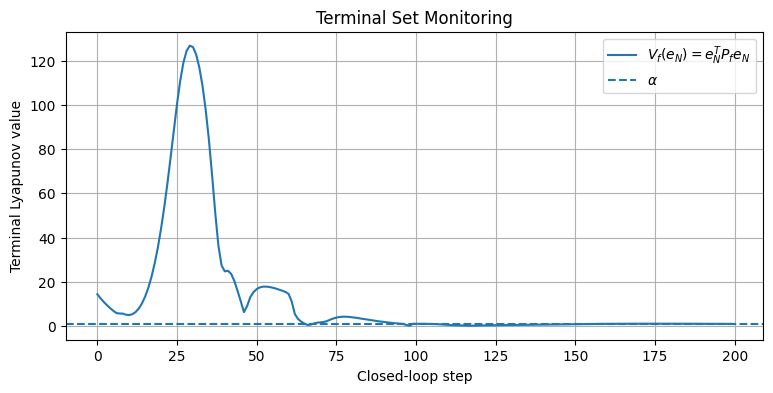

In [53]:
plt.figure(figsize=(9, 4))
plt.plot(V_terminal_hist.numpy(), label=r"$V_f(e_N) = e_N^T P_f e_N$")
plt.axhline(alpha, linestyle="--", label=r"$\alpha$")

plt.xlabel("Closed-loop step")
plt.ylabel("Terminal Lyapunov value")
plt.title("Terminal Set Monitoring")
plt.legend()
plt.grid(True)
plt.show()

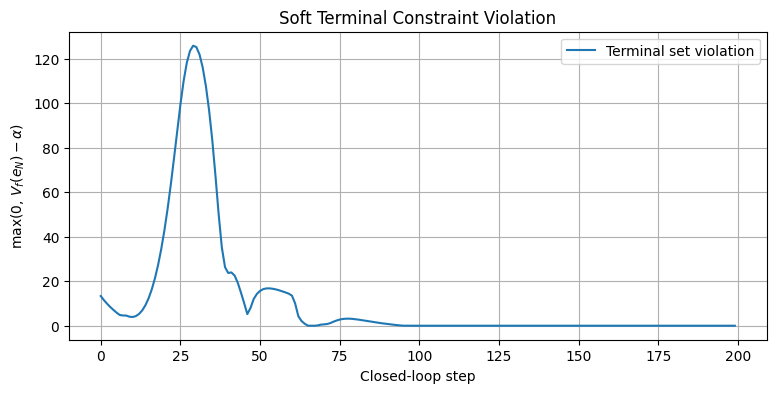

In [54]:
plt.figure(figsize=(9, 4))
plt.plot(violation_hist.numpy(), label="Terminal set violation")

plt.xlabel("Closed-loop step")
plt.ylabel(r"max(0, $V_f(e_N)-\alpha$)")
plt.title("Soft Terminal Constraint Violation")
plt.legend()
plt.grid(True)
plt.show()

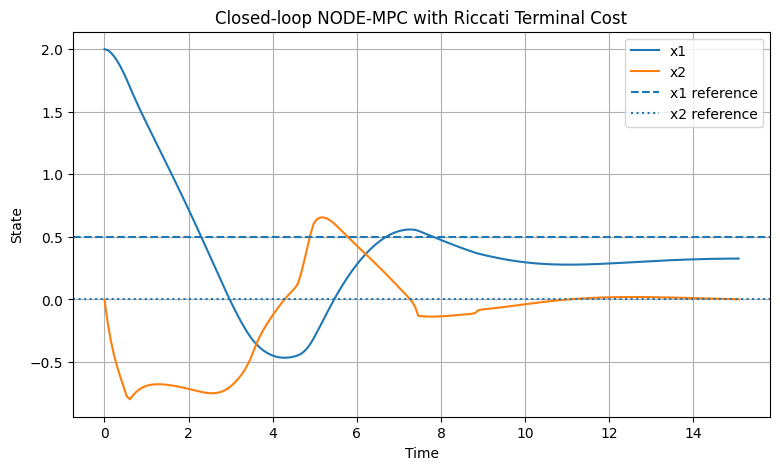

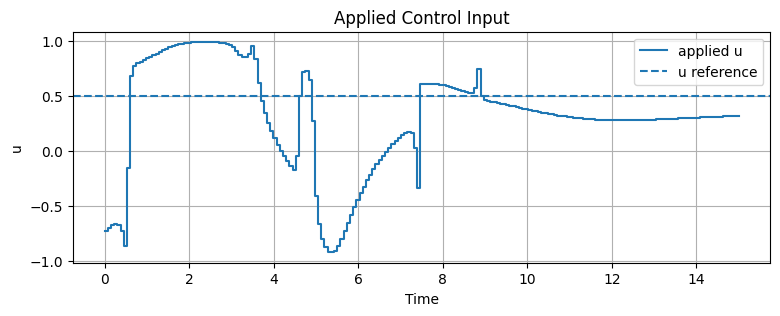

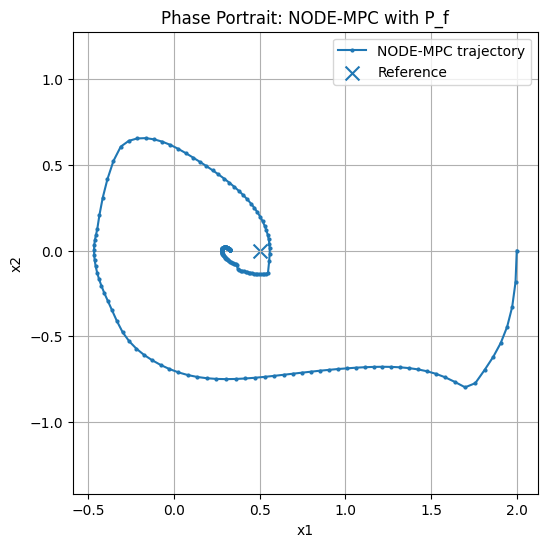

In [56]:
x_ref_cpu = x_ref.detach().cpu()
u_ref_cpu = u_ref.detach().cpu()

t_sim = torch.arange(x_hist_node_ts.shape[0]) * dt
t_u = torch.arange(u_hist_node_ts.shape[0]) * dt

plt.figure(figsize=(9, 5))
plt.plot(t_sim.numpy(), x_hist_node_ts[:, 0].numpy(), label="x1")
plt.plot(t_sim.numpy(), x_hist_node_ts[:, 1].numpy(), label="x2")

plt.axhline(x_ref_cpu[0].item(), linestyle="--", label="x1 reference")
plt.axhline(x_ref_cpu[1].item(), linestyle=":", label="x2 reference")

plt.xlabel("Time")
plt.ylabel("State")
plt.title("Closed-loop NODE-MPC with Riccati Terminal Cost")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(9, 3))
plt.step(t_u.numpy(), u_hist_node_ts[:, 0].numpy(), where="post", label="applied u")
plt.axhline(u_ref_cpu[0].item(), linestyle="--", label="u reference")

plt.xlabel("Time")
plt.ylabel("u")
plt.title("Applied Control Input")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(6, 6))
plt.plot(
    x_hist_node_ts[:, 0].numpy(),
    x_hist_node_ts[:, 1].numpy(),
    marker="o",
    markersize=2,
    label="NODE-MPC trajectory"
)

plt.scatter(
    [x_ref_cpu[0].item()],
    [x_ref_cpu[1].item()],
    marker="x",
    s=100,
    label="Reference"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Phase Portrait: NODE-MPC with P_f")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

In [57]:
def curvature_penalty_from_input(u_seq, epsilon=0.05, rho_eta=1.0):
    """
    Paper-inspired curvature penalty.

    delta2_u_s = u_s - 2u_{s-1} + u_{s-2}

    Soft slack:
        eta_s = max(0, |delta2_u_s| - epsilon)

    Penalty:
        rho_eta * sum(|eta_s|)

    u_seq shape: [Np, input_dim]
    """

    if u_seq.shape[0] < 3:
        zero = torch.zeros((), device=u_seq.device, dtype=u_seq.dtype)
        return zero, zero, zero

    delta2_u = u_seq[2:] - 2.0 * u_seq[1:-1] + u_seq[:-2]

    eta = torch.relu(torch.abs(delta2_u) - epsilon)

    curvature_penalty = rho_eta * torch.sum(eta)

    max_abs_delta2 = torch.max(torch.abs(delta2_u))
    mean_eta = torch.mean(eta)

    return curvature_penalty, max_abs_delta2, mean_eta

In [58]:
# Cost with curvature penalty:
# J = sum e_k^T Q e_k + sum v_k^T R v_k + e_N^T P_f e_N + lambda * max(0, eN^T P_f eN - alpha)^2 + rho_eta * sum |eta_s|


def mpc_cost_with_terminal_set_and_curvature(
    states,
    u_seq,
    x_ref,
    u_ref,
    Q,
    R,
    P_f,
    alpha=None,
    lambda_alpha=0.0,
    epsilon_curv=0.05,
    rho_eta=1.0,
    return_info=False
):
    """
    MPC cost with:
        1. stage state cost
        2. stage input cost
        3. Riccati terminal cost
        4. soft terminal set penalty
        5. paper-inspired curvature slack penalty
    """

    state_err = states[:-1] - x_ref.unsqueeze(0)
    input_err = u_seq - u_ref.unsqueeze(0)

    state_cost = torch.einsum(
        "ki,ij,kj->",
        state_err,
        Q,
        state_err
    )

    input_cost = torch.einsum(
        "ki,ij,kj->",
        input_err,
        R,
        input_err
    )

    terminal_err = states[-1] - x_ref

    terminal_value = terminal_err @ P_f @ terminal_err
    terminal_cost = terminal_value

    if alpha is None or lambda_alpha == 0.0:
        terminal_set_violation = torch.zeros(
            (),
            device=states.device,
            dtype=states.dtype
        )
        terminal_set_penalty = torch.zeros(
            (),
            device=states.device,
            dtype=states.dtype
        )
    else:
        alpha_tensor = torch.as_tensor(
            alpha,
            device=states.device,
            dtype=states.dtype
        )

        terminal_set_violation = torch.relu(
            terminal_value - alpha_tensor
        )

        terminal_set_penalty = lambda_alpha * terminal_set_violation**2

    curvature_penalty, max_abs_delta2_u, mean_eta = curvature_penalty_from_input(
        u_seq=u_seq,
        epsilon=epsilon_curv,
        rho_eta=rho_eta
    )

    total_cost = (
        state_cost
        + input_cost
        + terminal_cost
        + terminal_set_penalty
        + curvature_penalty
    )

    if return_info:
        info = {
            "state_cost": state_cost,
            "input_cost": input_cost,
            "terminal_value": terminal_value,
            "terminal_cost": terminal_cost,
            "terminal_set_violation": terminal_set_violation,
            "terminal_set_penalty": terminal_set_penalty,
            "curvature_penalty": curvature_penalty,
            "max_abs_delta2_u": max_abs_delta2_u,
            "mean_eta": mean_eta,
            "total_cost": total_cost,
        }

        return total_cost, info

    return total_cost

In [62]:
def solve_mpc(
    prediction_func,
    x_current,
    x_ref,
    u_ref,
    Q,
    R,
    P_f,
    alpha=None,
    lambda_alpha=0.0,
    epsilon_curv=0.05,
    rho_eta=1.0,
    Np=20,
    dt=0.075,
    num_iters=200,
    lr=0.02,
    u_max=1.0
):
    """
    Solve NODE-MPC with:
        terminal cost
        soft terminal set
        curvature penalty
    """

    # Warn start 
    ratio = (u_ref / u_max).clamp(-0.95, 0.95)
    raw_init = torch.atanh(ratio).repeat(Np, 1).detach()
    raw_u = raw_init.clone().to(device).requires_grad_(True)

    optimizer = torch.optim.Adam([raw_u], lr=lr)

    cost_history = []

    for it in range(num_iters):
        optimizer.zero_grad()

        u_seq = u_max * torch.tanh(raw_u)

        states = rollout_dynamics(
            dynamics_func=prediction_func,
            x0=x_current,
            u_seq=u_seq,
            dt=dt
        )

        cost, info = mpc_cost_with_terminal_set_and_curvature(
            states=states,
            u_seq=u_seq,
            x_ref=x_ref,
            u_ref=u_ref,
            Q=Q,
            R=R,
            P_f=P_f,
            alpha=alpha,
            lambda_alpha=lambda_alpha,
            epsilon_curv=epsilon_curv,
            rho_eta=rho_eta,
            return_info=True
        )

        cost.backward()
        optimizer.step()

        cost_history.append(cost.item())

    with torch.no_grad():
        u_opt = u_max * torch.tanh(raw_u)

        states_opt = rollout_dynamics(
            dynamics_func=prediction_func,
            x0=x_current,
            u_seq=u_opt,
            dt=dt
        )

        _, info_tensor = mpc_cost_with_terminal_set_and_curvature(
            states=states_opt,
            u_seq=u_opt,
            x_ref=x_ref,
            u_ref=u_ref,
            Q=Q,
            R=R,
            P_f=P_f,
            alpha=alpha,
            lambda_alpha=lambda_alpha,
            epsilon_curv=epsilon_curv,
            rho_eta=rho_eta,
            return_info=True
        )

    info_final = {
        k: v.detach().cpu().item()
        for k, v in info_tensor.items()
    }

    final_cost = cost_history[-1]

    return u_opt.detach(), states_opt.detach(), cost_history, final_cost, info_final

In [63]:
def simulate_closed_loop_mpc(
    prediction_func,
    plant_func,
    x_init,
    x_ref,
    u_ref,
    Q,
    R,
    P_f,
    alpha=None,
    lambda_alpha=0.0,
    epsilon_curv=0.05,
    rho_eta=1.0,
    sim_steps=200,
    Np=20,
    dt=0.075,
    u_max=1.0,
    num_iters=200,
    lr=0.02
):
    x = x_init.clone().to(device)

    x_history = [x.squeeze(0).detach().cpu()]
    u_history = []

    terminal_value_history = []
    terminal_violation_history = []
    curvature_penalty_history = []
    max_abs_delta2_history = []
    mean_eta_history = []
    final_cost_history = []

    for step in range(sim_steps):
        u_opt, states_opt, cost_history, final_cost, final_info = solve_mpc(
            prediction_func=prediction_func,
            x_current=x,
            x_ref=x_ref,
            u_ref=u_ref,
            Q=Q,
            R=R,
            P_f=P_f,
            alpha=alpha,
            lambda_alpha=lambda_alpha,
            epsilon_curv=epsilon_curv,
            rho_eta=rho_eta,
            Np=Np,
            dt=dt,
            u_max=u_max,
            num_iters=num_iters,
            lr=lr
        )

        u0 = u_opt[0:1, :]

        x = rk4_step(
            dynamics_func=plant_func,
            x=x,
            u=u0,
            dt=dt
        )

        x_history.append(x.squeeze(0).detach().cpu())
        u_history.append(u0.squeeze(0).detach().cpu())

        terminal_value_history.append(final_info["terminal_value"])
        terminal_violation_history.append(final_info["terminal_set_violation"])
        curvature_penalty_history.append(final_info["curvature_penalty"])
        max_abs_delta2_history.append(final_info["max_abs_delta2_u"])
        mean_eta_history.append(final_info["mean_eta"])
        final_cost_history.append(final_cost)

        if step % 10 == 0:
            print(
                f"Step {step:3d} | "
                f"x = {x.squeeze(0).detach().cpu().numpy()} | "
                f"u = {u0.item(): .4f} | "
                f"V_N = {final_info['terminal_value']:.4f} | "
                f"term viol = {final_info['terminal_set_violation']:.4f} | "
                f"max Δ²u = {final_info['max_abs_delta2_u']:.4f} | "
                f"mean η = {final_info['mean_eta']:.4f}"
            )

    x_history = torch.stack(x_history, dim=0)
    u_history = torch.stack(u_history, dim=0)

    logs = {
        "terminal_value": torch.tensor(terminal_value_history),
        "terminal_violation": torch.tensor(terminal_violation_history),
        "curvature_penalty": torch.tensor(curvature_penalty_history),
        "max_abs_delta2_u": torch.tensor(max_abs_delta2_history),
        "mean_eta": torch.tensor(mean_eta_history),
        "final_cost": torch.tensor(final_cost_history),
    }

    return x_history, u_history, logs

In [64]:
alpha = 1.0
lambda_alpha = 10.0

epsilon_curv = 0.05
rho_eta = 1.0

x_hist_node_curv, u_hist_node_curv, logs_curv = simulate_closed_loop_mpc(
    prediction_func=node_func,
    plant_func=true_func,
    x_init=x_init,
    x_ref=x_ref,
    u_ref=u_ref,
    Q=Q,
    R=R,
    P_f=P_f,
    alpha=alpha,
    lambda_alpha=lambda_alpha,
    epsilon_curv=epsilon_curv,
    rho_eta=rho_eta,
    sim_steps=200,
    Np=20,
    dt=dt,
    u_max=1.0,
    num_iters=200,
    lr=0.02
)

Step   0 | x = [ 1.992801   -0.18402503] | u = -0.7290 | V_N = 14.3341 | term viol = 13.3341 | max Δ²u = 0.0730 | mean η = 0.0042
Step  10 | x = [ 1.5281414 -0.719289 ] | u =  0.7953 | V_N = 4.9170 | term viol = 3.9170 | max Δ²u = 0.0039 | mean η = 0.0000
Step  20 | x = [ 1.0106329  -0.68703717] | u =  0.9393 | V_N = 44.1245 | term viol = 43.1245 | max Δ²u = 0.0019 | mean η = 0.0000
Step  30 | x = [ 0.47289628 -0.7423222 ] | u =  0.9862 | V_N = 126.2625 | term viol = 125.2625 | max Δ²u = 0.0006 | mean η = 0.0000
Step  40 | x = [-0.07841495 -0.66725934] | u =  0.9420 | V_N = 24.7048 | term viol = 23.7048 | max Δ²u = 0.0120 | mean η = 0.0000
Step  50 | x = [-0.42344263 -0.20622747] | u =  0.3404 | V_N = 16.6736 | term viol = 15.6736 | max Δ²u = 0.0310 | mean η = 0.0000
Step  60 | x = [-0.4475819   0.12578985] | u = -0.0433 | V_N = 14.5261 | term viol = 13.5261 | max Δ²u = 0.1827 | mean η = 0.0074
Step  70 | x = [-0.06767631  0.63495624] | u = -0.9122 | V_N = 1.6001 | term viol = 0.6001 |

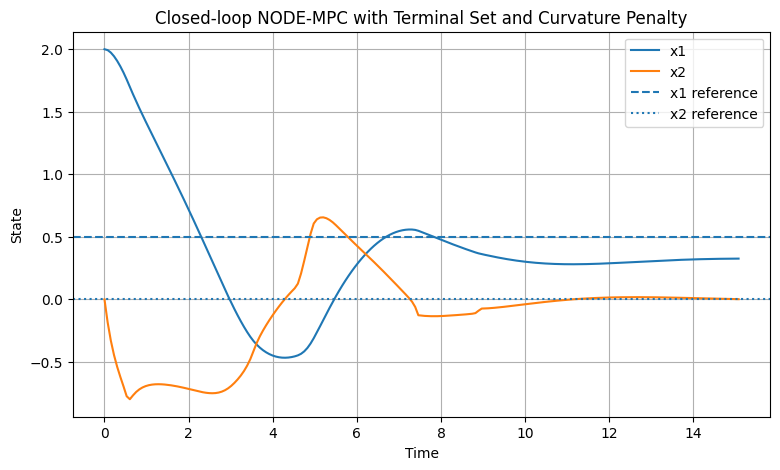

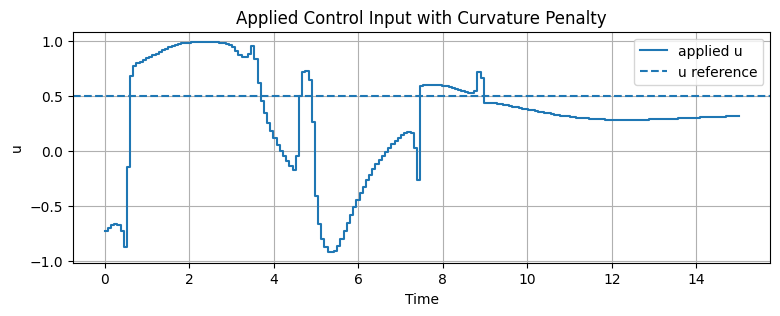

In [65]:
x_ref_cpu = x_ref.detach().cpu()
u_ref_cpu = u_ref.detach().cpu()

t_sim = torch.arange(x_hist_node_curv.shape[0]) * dt
t_u = torch.arange(u_hist_node_curv.shape[0]) * dt

plt.figure(figsize=(9, 5))
plt.plot(t_sim.numpy(), x_hist_node_curv[:, 0].numpy(), label="x1")
plt.plot(t_sim.numpy(), x_hist_node_curv[:, 1].numpy(), label="x2")
plt.axhline(x_ref_cpu[0].item(), linestyle="--", label="x1 reference")
plt.axhline(x_ref_cpu[1].item(), linestyle=":", label="x2 reference")
plt.xlabel("Time")
plt.ylabel("State")
plt.title("Closed-loop NODE-MPC with Terminal Set and Curvature Penalty")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(9, 3))
plt.step(t_u.numpy(), u_hist_node_curv[:, 0].numpy(), where="post", label="applied u")
plt.axhline(u_ref_cpu[0].item(), linestyle="--", label="u reference")
plt.xlabel("Time")
plt.ylabel("u")
plt.title("Applied Control Input with Curvature Penalty")
plt.legend()
plt.grid(True)
plt.show()

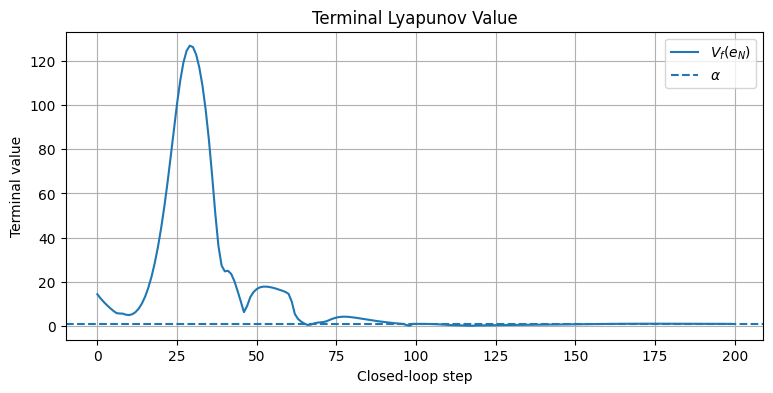

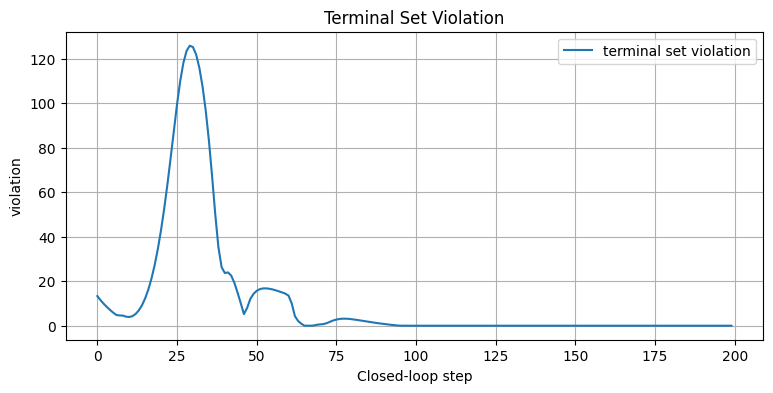

In [66]:
plt.figure(figsize=(9, 4))
plt.plot(logs_curv["terminal_value"].numpy(), label=r"$V_f(e_N)$")
plt.axhline(alpha, linestyle="--", label=r"$\alpha$")
plt.xlabel("Closed-loop step")
plt.ylabel("Terminal value")
plt.title("Terminal Lyapunov Value")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(9, 4))
plt.plot(logs_curv["terminal_violation"].numpy(), label="terminal set violation")
plt.xlabel("Closed-loop step")
plt.ylabel("violation")
plt.title("Terminal Set Violation")
plt.legend()
plt.grid(True)
plt.show()

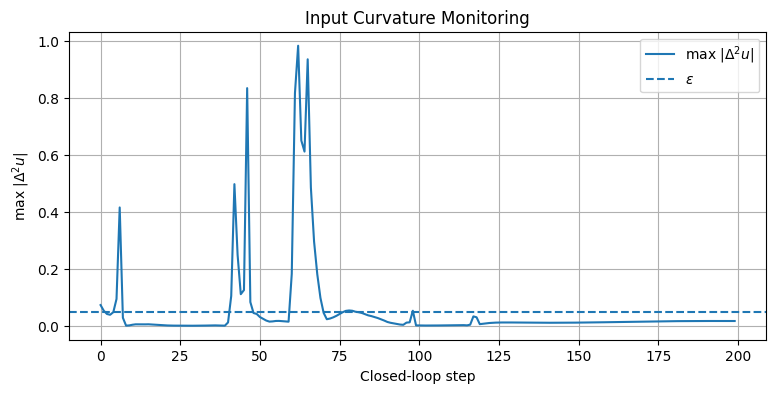

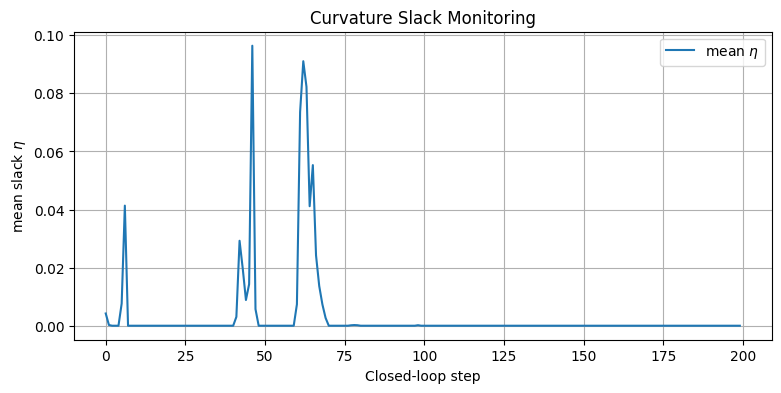

In [67]:
plt.figure(figsize=(9, 4))
plt.plot(logs_curv["max_abs_delta2_u"].numpy(), label=r"max $|\Delta^2 u|$")
plt.axhline(epsilon_curv, linestyle="--", label=r"$\epsilon$")
plt.xlabel("Closed-loop step")
plt.ylabel(r"max $|\Delta^2 u|$")
plt.title("Input Curvature Monitoring")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(9, 4))
plt.plot(logs_curv["mean_eta"].numpy(), label=r"mean $\eta$")
plt.xlabel("Closed-loop step")
plt.ylabel(r"mean slack $\eta$")
plt.title("Curvature Slack Monitoring")
plt.legend()
plt.grid(True)
plt.show()